# 2/7 - C. WHERE - zone, channel, defensive line, shape
Pressure by third (zone press), by left / centre / right and the 3x3 zone x channel grid, pressure heatmap, defensive line height / tilt / events, team compactness.

*Original sections: sections 5, 5b, 11, 6, 7, 6b, 18.*  Barca (team 0) vs Atletico (team 1), first half.

**Run the notebooks in order** (each one reads what the earlier ones saved in `new_cache/pressure_analysis/state/`):

| # | notebook | what it covers |
|---|---|---|
| 1 | 01_pressure_signal.ipynb | B. The pressure signal |
| 2 | **02_where_zone_channel_line.ipynb** | C. WHERE - zone, channel, defensive line, shape |
| 3 | 03_timing_and_possession.ipynb | D. WHEN - reaction speed and possession-level pressure |
| 4 | 04_passes_outcomes_triggers.ipynb | E/F. EFFECT and TRIGGERS |
| 5 | 05_summary_and_registry.ipynb | G/H. Summary + event registry |
| 6 | 06_clips.ipynb | H. Clips |
| 7 | 07_exports.ipynb | I. Exports |

Shared setup (paths, tables, data contract, team-label orientation, helpers) lives in `pressure_common.py` - keep it in the same folder as the notebooks.

In [1]:
from pressure_common import *

player table: player_frame_table_named.parquet (1593443, 41)
ball table  : ball_frame_table_named.parquet (70327, 22)
column guard: dropped from the player table (the ball table is the source for these): ['carrier_track_id', 'is_stoppage', 'possession_team']
ORIENTATION: table had team 0 attacking -x / team 1 attacking +x -> team ids swapped on load (now team 0 attacks +x, team 1 attacks -x, as the analysis cells assume)
TEAM_NAMES: {0: 'Barca', 1: 'Atletico'}
ball-table carrier_team agrees with the player table's team ids on 100.0% of carrier frames

roles: {'player': 1351246, 'referee': 179020, 'goalkeeper': 63177}
frames 0..70325 | ball rows 70327 | carrier coverage 48.8% | goalkeepers [1, 2]
data contract OK


In [2]:
# handed over by the earlier notebooks:
#   01_pressure_signal: BOX_DEPTH_M, ball_pos_by_frame, team_pressure_events, team_pressure_full, tpf
load_state(globals(), [
    'BOX_DEPTH_M',
    'ball_pos_by_frame',
    'team_pressure_events',
    'team_pressure_full',
    'tpf',
])

loaded 5 variables from C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\pressure_analysis\state


## 5. Pressure by pitch zone (own / middle / attacking third, relative to pressing team's attack direction)
Uses the corrected `under_team_pressure` from section 3 (already excludes own-box frames).

In [3]:
tpf_zone = team_pressure_full.copy()

def classify_zone(row):
    x = row["press_x"]
    if pd.isna(x):
        return None
    if row["team"] == 0:
        if x < 35: return "own_third"
        elif x < 70: return "middle_third"
        else: return "attacking_third"
    else:
        if x > 70: return "own_third"
        elif x > 35: return "middle_third"
        else: return "attacking_third"

tpf_zone["press_zone"] = tpf_zone.apply(classify_zone, axis=1)

pressing_only = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna()]

zone_counts = pressing_only.groupby(["team", "press_zone"]).size().unstack(fill_value=0)
zone_pct = zone_counts.div(zone_counts.sum(axis=1), axis=0) * 100

print("pressure frames by team and zone:\n", zone_counts)
print("\n% distribution within each team's own pressing:\n", zone_pct)


pressure frames by team and zone:
 press_zone  attacking_third  middle_third  own_third
team                                                
0.0                    1144          1125        263
1.0                     230          1561       1481

% distribution within each team's own pressing:
 press_zone  attacking_third  middle_third  own_third
team                                                
0.0               45.181675     44.431280  10.387046
1.0                7.029340     47.707824  45.262836


## 5b. Pressure by channel (left / centre / right) and the zone x channel grid
Section 5 only splits pressure by **third**. This adds the lateral split, so "where a team presses" becomes a 3 x 3 grid (own / middle / attacking third x left / centre / right). Channels are measured from the **pressing team's own attacking direction** (left = the pressing team's left when it faces the opposition goal), same convention as the zones. If left/right come out mirrored against what you see on video, set `FLIP_CHANNELS = True`.


pressure frames by team and channel (pressing team's own left/right):
 press_channel  left  centre  right
team                              
0.0             737     635   1160
1.0            1006     783   1483

% within each team's own pressing:
 press_channel  left  centre  right
team                              
0.0            29.1    25.1   45.8
1.0            30.7    23.9   45.3

zone x channel, % of the team's pressure frames:
 press_channel         left  centre  right
team press_zone                          
0    own_third         5.3     1.9    3.2
     middle_third     14.2     8.4   21.8
     attacking_third   9.6    14.8   20.8
1    own_third        15.2     9.0   21.1
     middle_third     11.6    13.6   22.6
     attacking_third   4.0     1.4    1.7


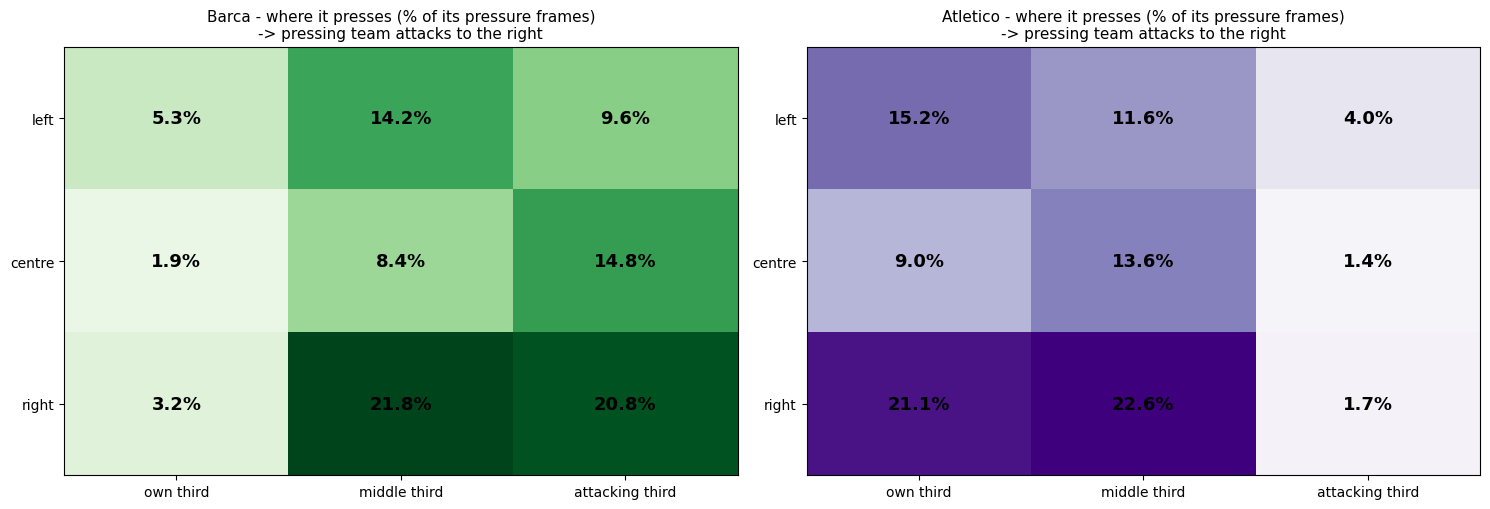

In [4]:
# zone_for_team / channel_for_team / CHANNEL_ORDER / ZONE_ORDER_5 / FLIP_CHANNELS come from pressure_common

tpf_zone["press_channel"] = [channel_for_team(y, t) for y, t in zip(tpf_zone["press_y"], tpf_zone["team"])]

pressing_zc = tpf_zone[tpf_zone["under_team_pressure"] & tpf_zone["press_zone"].notna() & tpf_zone["press_channel"].notna()]

channel_counts = (pressing_zc.groupby(["team", "press_channel"]).size().unstack(fill_value=0)
                  .reindex(columns=CHANNEL_ORDER, fill_value=0))
channel_pct = channel_counts.div(channel_counts.sum(axis=1), axis=0) * 100

zone_channel_counts = (pressing_zc.groupby(["team", "press_zone", "press_channel"]).size().unstack(fill_value=0)
                       .reindex(columns=CHANNEL_ORDER, fill_value=0)
                       .reindex(pd.MultiIndex.from_product([[0, 1], ZONE_ORDER_5], names=["team", "press_zone"]), fill_value=0))
# % of each team's pressure frames (not per-zone row), computed without .loc[...] = DataFrame,
# which tries to align on the full (team, zone) MultiIndex and fills everything with NaN
_team_tot = zone_channel_counts.sum(axis=1).groupby(level="team").transform("sum").replace(0, np.nan)
zone_channel_pct = zone_channel_counts.div(_team_tot, axis=0).fillna(0.0) * 100

print("pressure frames by team and channel (pressing team's own left/right):\n", channel_counts)
print("\n% within each team's own pressing:\n", channel_pct.round(1))
print("\nzone x channel, % of the team's pressure frames:\n", zone_channel_pct.round(1))

# 3 x 3 grids, drawn in each pressing team's own frame (own goal on the left, left channel at the top)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
for ax, team_id, cmap in zip(axes, [0, 1], ["Greens", "Purples"]):
    grid = zone_channel_pct.loc[team_id].reindex(ZONE_ORDER_5).T.reindex(CHANNEL_ORDER)       # rows = channel, cols = zone
    ax.imshow(grid.values, cmap=cmap, aspect="auto", vmin=0, vmax=max(grid.values.max(), 1))
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{grid.values[i, j]:.1f}%", ha="center", va="center", fontsize=13, weight="bold")
    ax.set_xticks(range(3)); ax.set_xticklabels(["own third", "middle third", "attacking third"])
    ax.set_yticks(range(3)); ax.set_yticklabels(CHANNEL_ORDER)
    ax.set_title(f"{TEAM_NAMES[team_id]} - where it presses (% of its pressure frames)\n-> pressing team attacks to the right", fontsize=11)
plt.tight_layout(); plt.show()


## 11. Pressure heatmap (spatial density on pitch)
Each team's own-goal orientation preserved (Barca attacks +x, own goal left; Atletico attacks -x, own goal right). Points outside the pitch bounds (homography noise) are dropped. Each hexbin is normalized to its own team's total so the comparison shows WHERE pressure concentrates, not raw volume (which is naturally higher for whichever team has less possession).

dropped 10 / 5804 pressure points outside pitch bounds (+/- 2.0m)
team
0.0    2522
1.0    3272
dtype: int64


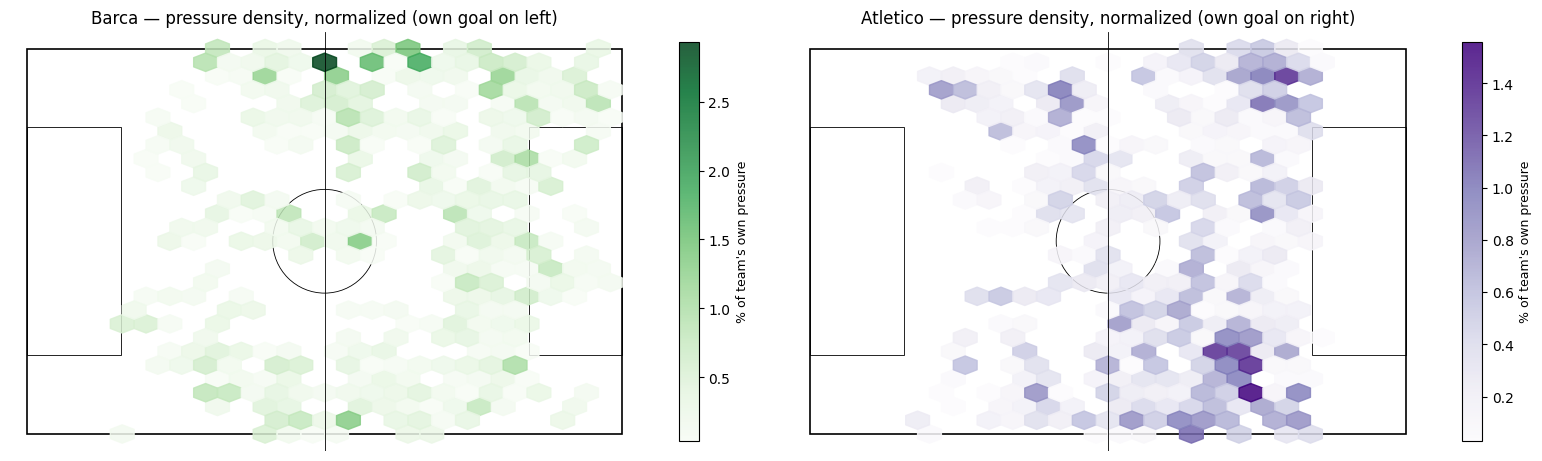

In [5]:
BOUNDS_TOLERANCE_M = 2.0

pressure_points = team_pressure_full[team_pressure_full["under_team_pressure"]].dropna(subset=["press_x", "press_y"]).copy()

pressure_points_clean = pressure_points[
    (pressure_points["press_x"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (pressure_points["press_y"] >= -BOUNDS_TOLERANCE_M) & (pressure_points["press_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
].copy()

n_dropped = len(pressure_points) - len(pressure_points_clean)
print(f"dropped {n_dropped} / {len(pressure_points)} pressure points outside pitch bounds (+/- {BOUNDS_TOLERANCE_M}m)")
print(pressure_points_clean.groupby("team").size())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, team_id, label, cmap in zip(axes, [0, 1], [TEAM_NAMES[0], TEAM_NAMES[1]], ["Greens", "Purples"]):
    sub = pressure_points_clean[pressure_points_clean["team"] == team_id]

    ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
    ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.6)
    ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.6))
    box_depth, box_width = 16.5, 40.3
    ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))
    ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.6))

    weights = np.full(len(sub), 1.0 / len(sub) * 100)
    hb = ax.hexbin(sub["press_x"], sub["press_y"], C=weights, reduce_C_function=np.sum,
                    gridsize=25, cmap=cmap, mincnt=1, extent=(0, PITCH_LENGTH, 0, PITCH_WIDTH), alpha=0.85)
    cb = plt.colorbar(hb, ax=ax, shrink=0.7)
    cb.set_label("% of team's own pressure", fontsize=9)

    own_goal_side = "left" if team_id == 0 else "right"
    ax.set_title(f"{label} — pressure density, normalized (own goal on {own_goal_side})", fontsize=12)
    ax.set_xlim(-3, PITCH_LENGTH + 3)
    ax.set_ylim(-3, PITCH_WIDTH + 3)
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [6]:
## Diagnostic: what's driving the concentrated corner-zone pressure cluster for team 0
## Checks whether the dark hex near the corner is one sustained passage of play or genuinely
## distributed events -- needed before deciding whether to change the in_own_box exclusion.

CORNER_ZONE_X_MAX = 30  # just beyond the 16.5m box exclusion, catches the corner/wide-defending band

corner_zone_events = team_pressure_events[
    (team_pressure_events["team"] == 0)
].copy()

# re-attach zone info by checking the ball position at event midpoint
corner_zone_events["mid_frame"] = ((corner_zone_events["start_frame"] + corner_zone_events["end_frame"]) / 2).astype(int)
ball_x_lookup = ball_frame_table.set_index("frame_idx")["ball_pitch_x"]
corner_zone_events["mid_press_x"] = corner_zone_events["mid_frame"].map(ball_x_lookup)

corner_zone_events = corner_zone_events[
    (corner_zone_events["mid_press_x"] > BOX_DEPTH_M) & (corner_zone_events["mid_press_x"] <= CORNER_ZONE_X_MAX)
].sort_values("duration_sec", ascending=False)

print(f"team 0 pressure events with midpoint between {BOX_DEPTH_M}m and {CORNER_ZONE_X_MAX}m from own goal:")
print(f"{len(corner_zone_events)} events, {corner_zone_events['duration_sec'].sum():.1f}s total")
print()
print(corner_zone_events[["start_frame", "end_frame", "duration_sec", "mean_n_pressing"]].head(10))

team 0 pressure events with midpoint between 16.5m and 30m from own goal:
2 events, 1.7s total

    start_frame  end_frame  duration_sec  mean_n_pressing
48        57570      57596          1.08         1.000000
27        35253      35267          0.60         1.733333


## 6. Defensive line height (distance from own goal, last-1 and last-3 defenders; out-of-possession frames only)

In [7]:
BOUNDS_TOLERANCE_M = 2.0

outfield = player_frame_table[player_frame_table["role"] == "player"].copy()
outfield = outfield.dropna(subset=["pitch_x", "pitch_y"])

in_bounds = (
    (outfield["pitch_x"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_x"] <= PITCH_LENGTH + BOUNDS_TOLERANCE_M) &
    (outfield["pitch_y"] >= -BOUNDS_TOLERANCE_M) & (outfield["pitch_y"] <= PITCH_WIDTH + BOUNDS_TOLERANCE_M)
)
outfield = outfield[in_bounds].copy()

outfield["dist_from_own_goal"] = np.where(
    outfield["team"] == 0,
    outfield["pitch_x"],
    PITCH_LENGTH - outfield["pitch_x"]
)
outfield["dist_from_own_goal"] = outfield["dist_from_own_goal"].clip(0, PITCH_LENGTH)

def compute_line_height(df, n_defenders):
    return (
        df.sort_values("dist_from_own_goal")
        .groupby(["frame_idx", "team"])
        .head(n_defenders)
        .groupby(["frame_idx", "team"], as_index=False)["dist_from_own_goal"]
        .mean()
        .rename(columns={"dist_from_own_goal": "line_height_m"})
    )

def remove_outliers_iqr(df, col, group_cols):
    parts = []
    for _, g in df.groupby(group_cols):
        q1, q3 = g[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        parts.append(g[(g[col] >= lo) & (g[col] <= hi)])
    return pd.concat(parts, ignore_index=True)

poss = ball_frame_table[["frame_idx", "possession_team"]]

# defending frames only (same convention as the notebook-1 baseline, 6b and section 18)
_of = outfield.merge(poss, on="frame_idx", how="left")
outfield_def = _of[_of["possession_team"].notna() & (_of["team"] != _of["possession_team"])].copy()

line_last1 = compute_line_height(outfield_def, 1).merge(poss, on="frame_idx", how="left")
line_last3 = compute_line_height(outfield_def, 3).merge(poss, on="frame_idx", how="left")

line_last1_clean = remove_outliers_iqr(line_last1, "line_height_m", ["team"])
line_last3_clean = remove_outliers_iqr(line_last3, "line_height_m", ["team"])

avg_line_height = line_last3_clean.groupby("team")["line_height_m"].mean()

print("last-1 defender:\n", line_last1_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))
print("\nlast-3 defenders avg:\n", line_last3_clean.groupby("team")["line_height_m"].agg(["mean", "median", "std"]))


last-1 defender:
            mean     median        std
team                                 
0.0   44.543276  48.109376  13.768272
1.0   25.844900  23.009159  14.015746

last-3 defenders avg:
            mean     median        std
team                                 
0.0   46.367837  49.199605  15.621022
1.0   27.131091  23.990947  14.174232


## 7. Defensive line height — pitch visualization

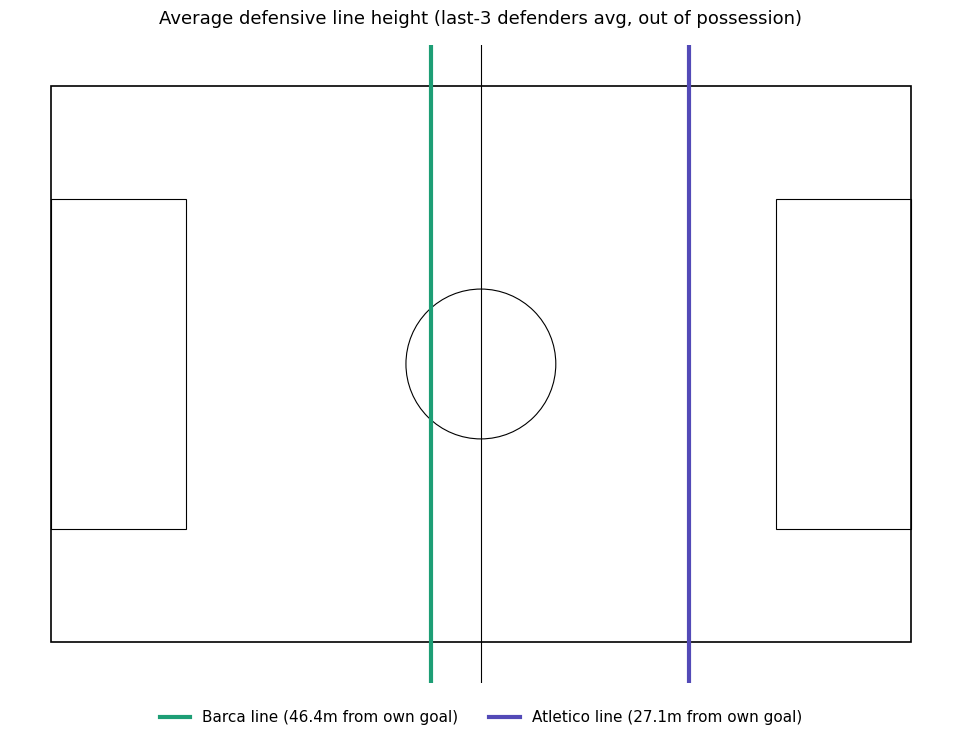

In [8]:
team0_line_x = avg_line_height[0]
team1_line_x = PITCH_LENGTH - avg_line_height[1]

fig, ax = plt.subplots(figsize=(12, 7.5))

ax.add_patch(patches.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", linewidth=1.2))
ax.axvline(PITCH_LENGTH / 2, color="black", linewidth=0.8)
ax.add_patch(patches.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", linewidth=0.8))

box_depth, box_width = 16.5, 40.3
ax.add_patch(patches.Rectangle((0, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))
ax.add_patch(patches.Rectangle((PITCH_LENGTH - box_depth, (PITCH_WIDTH - box_width) / 2), box_depth, box_width, fill=False, color="black", linewidth=0.8))

ax.axvline(team0_line_x, color="#1D9E75", linewidth=3, label=f"{TEAM_NAMES[0]} line ({team0_line_x:.1f}m from own goal)")
ax.axvline(team1_line_x, color="#534AB7", linewidth=3, label=f"{TEAM_NAMES[1]} line ({avg_line_height[1]:.1f}m from own goal)")

ax.set_xlim(-5, PITCH_LENGTH + 5)
ax.set_ylim(-5, PITCH_WIDTH + 5)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2, frameon=False, fontsize=11)
ax.set_title("Average defensive line height (last-3 defenders avg, out of possession)", fontsize=13, pad=15)

plt.tight_layout()
plt.show()


## 6b. Defensive line structure - height, left-right tilt, by ball zone, and line events
Section 6 gives one average line height per team. This keeps the **per-frame line state** (out-of-possession frames only) so the line can be broken down and clipped:

- `line_last1_m` / `line_last3_m` - height of the deepest defender / average of the deepest three (m from own goal).
- `line_tilt_m` - **left-right tilt**: mean height of the back-4 players on the left half minus the right half (positive = left side of the line is higher). Shows whether the line leans toward the ball side.
- `line_by_ball_zone` / `line_by_ball_channel` - how the line behaves when the ball is in each third / each channel.
- `defensive_line_events` - sustained **high line**, sustained **deep line** (team's own 80th / 20th percentile, >= `MIN_LINE_EVENT_SEC`) and **line step-ups** (line rises >= `LINE_STEP_UP_M` within `LINE_STEP_UP_WINDOW_SEC`).


defensive line (last-3, m from own goal) by where the ball is, relative to the DEFENDING team:
                       mean  median  count
team ball_zone                           
0.0  attacking_third  56.5    54.5   9427
     middle_third     42.1    41.7   6804
     own_third        17.6    16.5   3144
1.0  attacking_third  47.7    46.2   5913
     middle_third     28.9    27.7  13689
     own_third        14.4    14.9  10198

line height and left-right tilt (+ = left side higher) by ball channel:
                    line_last3_m  tilt_m      n
team ball_channel                             
0.0  centre               49.27   -1.03   6181
     left                 40.01   -1.13   6079
     right                45.92   -0.40   7115
1.0  centre               30.06   -0.04  10030
     left                 25.33    0.29   8844
     right                27.38   -0.02  10926

defensive-line events:
 subtype  deep_line  high_line  line_step_up
team                                       
0    

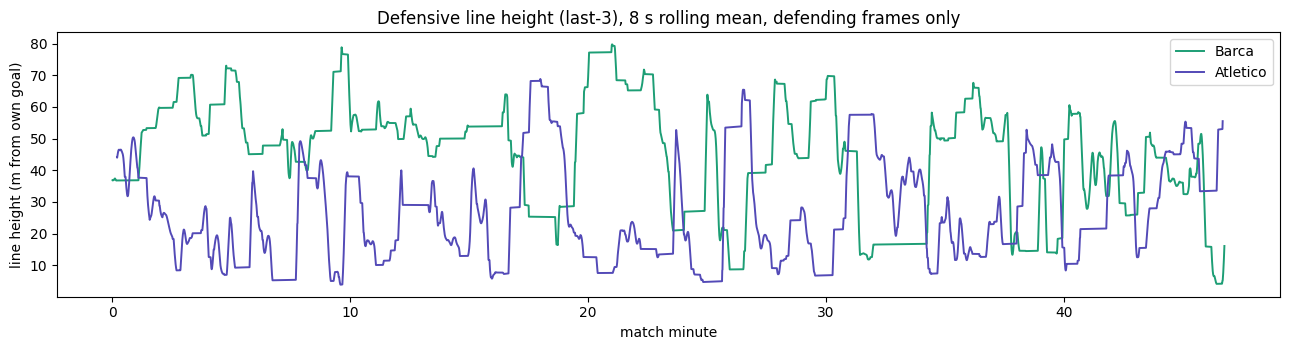

In [9]:
BACK_N_TILT = 4
HIGH_LINE_PCTL, DEEP_LINE_PCTL = 80, 20
MIN_LINE_EVENT_SEC = 3.0
LINE_STEP_UP_M, LINE_STEP_UP_WINDOW_SEC = 8.0, 2.0

_ls = outfield.merge(poss, on="frame_idx", how="left")
_ls = _ls[_ls["possession_team"].notna() & (_ls["team"] != _ls["possession_team"])].copy()      # defending frames only
_ls["y_att"] = np.where(_ls["team"] == 0, _ls["pitch_y"], PITCH_WIDTH - _ls["pitch_y"])
if FLIP_CHANNELS:
    _ls["y_att"] = PITCH_WIDTH - _ls["y_att"]
_ls = _ls.sort_values(["frame_idx", "team", "dist_from_own_goal"])
_ls["rank_back"] = _ls.groupby(["frame_idx", "team"]).cumcount()
_back = _ls[_ls["rank_back"] < BACK_N_TILT]
_key = ["frame_idx", "team"]

line_state = pd.concat({
    "line_last1_m": _back[_back["rank_back"] == 0].set_index(_key)["dist_from_own_goal"],
    "line_last3_m": _back[_back["rank_back"] < 3].groupby(_key)["dist_from_own_goal"].mean(),
    "_left": _back[_back["y_att"] < PITCH_WIDTH / 2].groupby(_key)["dist_from_own_goal"].mean(),
    "_right": _back[_back["y_att"] >= PITCH_WIDTH / 2].groupby(_key)["dist_from_own_goal"].mean(),
    "line_width_m": _back.groupby(_key)["y_att"].agg(lambda s: s.max() - s.min()),
    "n_back": _back.groupby(_key).size(),
}, axis=1).reset_index()
line_state["line_tilt_m"] = line_state["_left"] - line_state["_right"]
line_state = line_state.drop(columns=["_left", "_right"]).dropna(subset=["line_last3_m"])
line_state = line_state[line_state["n_back"] >= 3].merge(ball_pos_by_frame.rename(columns={"press_x": "ball_x", "press_y": "ball_y"}), on="frame_idx", how="left")

line_state["ball_zone"] = [zone_for_team(x, t) if pd.notna(x) else None for x, t in zip(line_state["ball_x"], line_state["team"])]
line_state["ball_channel"] = [channel_for_team(y, t) if pd.notna(y) else None for y, t in zip(line_state["ball_y"], line_state["team"])]

line_by_ball_zone = (line_state.groupby(["team", "ball_zone"])["line_last3_m"].agg(["mean", "median", "count"]).round(1))
line_by_ball_channel = (line_state.groupby(["team", "ball_channel"]).agg(line_last3_m=("line_last3_m", "mean"), tilt_m=("line_tilt_m", "mean"), n=("line_tilt_m", "size")).round(2))
print("defensive line (last-3, m from own goal) by where the ball is, relative to the DEFENDING team:\n", line_by_ball_zone)
print("\nline height and left-right tilt (+ = left side higher) by ball channel:\n", line_by_ball_channel)

# ---- line events
_ev = []
for _t, _g in line_state.groupby("team"):
    _g = _g.sort_values("frame_idx"); fr_ = _g["frame_idx"].values; h = _g["line_last3_m"].values
    hi, lo = np.percentile(h, HIGH_LINE_PCTL), np.percentile(h, DEEP_LINE_PCTL)
    for sub, mask in [("high_line", h >= hi), ("deep_line", h <= lo)]:
        for a, b in mask_runs(fr_, mask, max_gap=5, min_len=int(MIN_LINE_EVENT_SEC * FPS)):
            seg = _g[(_g["frame_idx"] >= a) & (_g["frame_idx"] <= b)]
            _ev.append(dict(team=int(_t), subtype=sub, start_frame=a, end_frame=b, mean_line_m=seg["line_last3_m"].mean(),
                            peak_line_m=seg["line_last3_m"].max() if sub == "high_line" else seg["line_last3_m"].min(), rise_m=np.nan))
    # step-ups: height now minus height `window` frames ago (only where both frames are defending frames)
    s_ = pd.Series(h, index=fr_); win = int(LINE_STEP_UP_WINDOW_SEC * FPS)
    prev = s_.reindex(fr_ - win).values
    rise = h - prev
    for a, b in mask_runs(fr_, np.nan_to_num(rise, nan=0) >= LINE_STEP_UP_M, max_gap=10, min_len=1):
        seg = _g[(_g["frame_idx"] >= a) & (_g["frame_idx"] <= b)]
        _ev.append(dict(team=int(_t), subtype="line_step_up", start_frame=a - win, end_frame=b, mean_line_m=seg["line_last3_m"].mean(),
                        peak_line_m=seg["line_last3_m"].max(), rise_m=float(np.nanmax(rise[(fr_ >= a) & (fr_ <= b)]))))
defensive_line_events = pd.DataFrame(_ev)
if len(defensive_line_events):
    defensive_line_events["duration_sec"] = (defensive_line_events["end_frame"] - defensive_line_events["start_frame"] + 1) / FPS
    print("\ndefensive-line events:\n", defensive_line_events.groupby(["team", "subtype"]).size().unstack(fill_value=0))
else:
    print("\nno defensive-line events found (check thresholds)")

fig, ax = plt.subplots(figsize=(13, 3.6))
for t, colr in [(0, "#1D9E75"), (1, "#534AB7")]:
    g = line_state[line_state["team"] == t].sort_values("frame_idx")
    ax.plot(g["frame_idx"] / FPS / 60, g["line_last3_m"].rolling(FPS * 8, min_periods=10).mean(), c=colr, lw=1.4, label=TEAM_NAMES[t])
ax.set_xlabel("match minute"); ax.set_ylabel("line height (m from own goal)"); ax.set_title("Defensive line height (last-3), 8 s rolling mean, defending frames only")
ax.legend(); plt.tight_layout(); plt.show()


## 18. Team shape compactness -- width and depth of the outfield block
Per-frame team depth (distance between the back line and the front line, along each team's own attack direction -- last-3 vs front-3 outfield players, same last-3 convention as the defensive-line baseline in section 0) and width (lateral spread across the pitch, IQR-trimmed so one stray tracked position doesn't blow up the number, same safeguard `remove_outliers_iqr` uses in section 6). Restricted to out-of-possession frames -- a team's real defensive shape, not inflated by attacking-phase positioning, same convention as everywhere else in this notebook. Reuses `outfield` (in-bounds, `dist_from_own_goal` already computed) and `poss` from section 6.

Also checks whether a team's shape actually tightens while actively pressing vs its resting out-of-possession shape. (Tried linking compactness to press-event regain outcomes too -- dropped: correlations with co-press count came back near zero and the regain-outcome split produced small, inconsistent, unexplainable cells across zones and teams. Not reliable enough to keep.)

In [10]:
BACK_N = 3
FRONT_N = 3
WIDTH_IQR_MULT = 1.5
MIN_PLAYERS_FOR_SHAPE = BACK_N + FRONT_N  # need enough tracked outfield players for depth to mean anything

_shape_base = outfield.merge(poss, on="frame_idx", how="left")
_shape_base = _shape_base[
    _shape_base["possession_team"].notna() & (_shape_base["team"] != _shape_base["possession_team"])
]

def _team_frame_depth(df):
    d = df.sort_values("dist_from_own_goal")
    n = len(d)
    if n < MIN_PLAYERS_FOR_SHAPE:
        return pd.Series({"back_line_m": np.nan, "front_line_m": np.nan, "depth_m": np.nan, "n_players": n})
    back = d.head(BACK_N)["dist_from_own_goal"].mean()
    front = d.tail(FRONT_N)["dist_from_own_goal"].mean()
    return pd.Series({"back_line_m": back, "front_line_m": front, "depth_m": front - back, "n_players": n})

def _team_frame_width(y_vals):
    y = np.asarray(y_vals)
    if len(y) < 4:
        return np.nan
    q1, q3 = np.percentile(y, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - WIDTH_IQR_MULT * iqr, q3 + WIDTH_IQR_MULT * iqr
    y_trimmed = y[(y >= lo) & (y <= hi)]
    return float(y_trimmed.max() - y_trimmed.min()) if len(y_trimmed) else np.nan

depth_per_frame = _shape_base.groupby(["frame_idx", "team"]).apply(_team_frame_depth).reset_index()
depth_per_frame = depth_per_frame.dropna(subset=["depth_m"])

width_per_frame = (
    _shape_base.groupby(["frame_idx", "team"])["pitch_y"]
    .apply(_team_frame_width)
    .reset_index(name="width_m")
)

team_shape = depth_per_frame.merge(width_per_frame, on=["frame_idx", "team"], how="inner")
team_shape["compactness_area_m2"] = team_shape["depth_m"] * team_shape["width_m"]

print("out-of-possession team shape, by team (smaller area = more compact block):")
print(team_shape.groupby("team")[["depth_m", "width_m", "compactness_area_m2"]].agg(["mean", "median", "std"]))

C:\Users\user\AppData\Local\Temp\ipykernel_24876\3672017474.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  depth_per_frame = _shape_base.groupby(["frame_idx", "team"]).apply(_team_frame_depth).reset_index()


out-of-possession team shape, by team (smaller area = more compact block):
        depth_m                         width_m                       \
           mean     median       std       mean     median       std   
team                                                                   
0.0   22.809678  23.337789  8.020347  35.824408  37.554335  9.879202   
1.0   19.343621  18.233403  6.882313  35.577268  36.408452  8.508119   

     compactness_area_m2                          
                    mean      median         std  
team                                              
0.0           850.103061  845.898006  387.244701  
1.0           709.939300  641.617288  343.378567  


In [11]:
# --- does a team actually get tighter when it's actively pressing, or is shape constant regardless? ---
team_shape_pressure = team_shape.merge(
    tpf[["frame_idx", "team", "under_team_pressure"]], on=["frame_idx", "team"], how="left"
)

print("compactness area (m^2) while actively pressing vs not, by team:")
print(
    team_shape_pressure.groupby(["team", "under_team_pressure"])["compactness_area_m2"]
    .agg(["mean", "median", "count"])
)

compactness area (m^2) while actively pressing vs not, by team:
                                mean      median  count
team under_team_pressure                               
0.0  False                836.222437  847.114197  10342
     True                 806.516675  782.782613   2532
1.0  False                717.737506  643.131902  16935
     True                 682.677634  613.655080   3272


## Hand-off
Saves what the later notebooks need.

In [12]:
save_state(globals(), [
    'BACK_N',
    'FRONT_N',
    'WIDTH_IQR_MULT',
    'channel_pct',
    'defensive_line_events',
    'line_by_ball_channel',
    'line_by_ball_zone',
    'line_last1_clean',
    'line_last3_clean',
    'line_state',
    'pressure_points_clean',
    'team_shape',
    'team_shape_pressure',
    'tpf_zone',
    'zone_channel_pct',
    'zone_counts',
    'zone_pct',
], notebook='02_where_zone_channel_line.ipynb')

saved 17 variables to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\barca_atletico_first_half\new_cache\pressure_analysis\state
  BACK_N                            int             0.00 MB
  FRONT_N                           int             0.00 MB
  WIDTH_IQR_MULT                    float           0.00 MB
  channel_pct                       DataFrame       0.00 MB
  defensive_line_events             DataFrame       0.01 MB
  line_by_ball_channel              DataFrame       0.00 MB
  line_by_ball_zone                 DataFrame       0.00 MB
  line_last1_clean                  DataFrame       1.75 MB
  line_last3_clean                  DataFrame       1.76 MB
  line_state                        DataFrame       4.21 MB
  pressure_points_clean             DataFrame       0.75 MB
  team_shape                        DataFrame       3.54 MB
  team_shape_pressure               DataFrame       3.77 MB
  tpf_zone                          DataFrame       4.22 MB
  zone